In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [5]:
df_lim = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

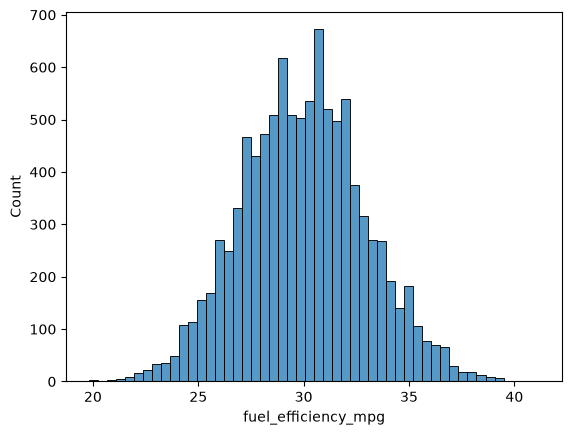

In [7]:
#It's normal distribution!
sns.histplot(df_lim.fuel_efficiency_mpg, bins=50)

In [8]:
#horsepower
df_lim.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [9]:
df_lim.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [10]:
#median 254
df_lim.horsepower.median()

np.float64(254.0)

In [92]:
# Here, we randomly (seed 42) divide dataset to 60% training, 20% validation and 20% test.
def split_dataset (df, y_col, rnd_no):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(rnd_no)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = np.log1p(df_train[y_col].values)
    y_val = np.log1p(df_val[y_col].values)
    y_test = np.log1p(df_test[y_col].values)

    del df_train[y_col]
    del df_val[y_col]
    del df_test[y_col]

    return df_train, df_val, df_test, y_train, y_val, y_test

In [19]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [21]:
def linear_regression(X):
    return X.dot(w_new)

In [22]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [61]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [114]:
def prepare_X(df, val_empty):
    df_num = df.copy()
    df_num = df_num.fillna(val_empty)
    X = df_num.values

    return X

In [110]:
def predict_using_linear_regression(df_train, val_empty):
    df_train = prepare_X(df_train, val_empty)
    X_train = df_train.values
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_train.dot(w)
    
    return y_pred

In [102]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [ ]:
df_train, df_val, df_test, y_train, y_val, y_test = split_dataset(df_lim, 'fuel_efficiency_mpg', 42)

In [111]:
#1st attemp results with nan. Problem: Null values on horsepower
X_train = df_train.values
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(nan), array([nan, nan, nan, nan]))

In [115]:
#2nd attempt: Fill null with 0. Result: Good ones
y_pred_0 = predict_using_linear_regression(df_train, 0)
sns.histplot(y_pred_0, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [77]:
score_zero = rmse(y_train, y_pred_0)
round(score_zero, 3)

np.float64(0.071)

In [70]:
#3rd attempt: Fill null values with mean.
df_mean = df_train.copy()
X_train_mean = df_mean.fillna(df_train.horsepower.mean()).values
w0, w = train_linear_regression(X_train_mean, y_train)
w0, w

(np.float64(-2.5457960895519833),
 array([-3.44278982e-05, -1.93797626e-04, -1.27256748e-04,  3.32443092e-03]))

<Axes: ylabel='Count'>

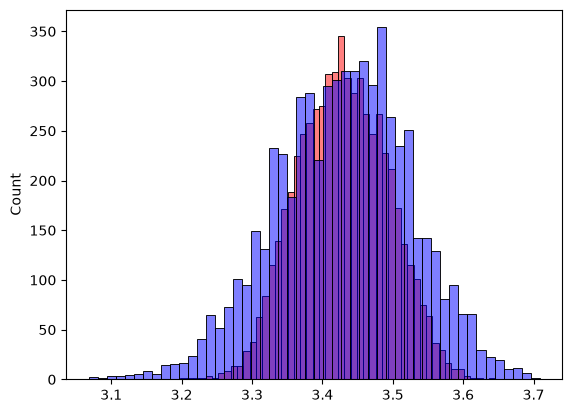

In [71]:
y_pred_m = w0 + X_train_mean.dot(w_m)
sns.histplot(y_pred_m, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [79]:
#So, both are equally good
score_m = rmse(y_train, y_pred_m)
round(score_m, 3)

np.float64(0.071)

In [ ]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    #Best is 100
    print('Regularization No: ', r,' | ', 'Baseline Weight: ', w0, ' | ', 'RMSE Score: ', score)

Regularization No:  0  |  Baseline Weight:  -2.548879880787878  |  RMSE Score:  0.07148851150946246
Regularization No:  0.01  |  Baseline Weight:  -2.456525696928604  |  RMSE Score:  0.07149325884153895
Regularization No:  0.1  |  Baseline Weight:  -1.8524448492907521  |  RMSE Score:  0.07165023237517189
Regularization No:  1  |  Baseline Weight:  -0.535529553803343  |  RMSE Score:  0.07274035044832705
Regularization No:  5  |  Baseline Weight:  -0.1287451934306354  |  RMSE Score:  0.0732791162252194
Regularization No:  10  |  Baseline Weight:  -0.06603998348984993  |  RMSE Score:  0.07337041231450352
Regularization No:  100  |  Baseline Weight:  -0.006760761337059787  |  RMSE Score:  0.07345871819237142
